# Pandas crash course


<img align="center" src="https://github.com/dfbarrero/dataCourse/raw/master/pandas/figs/pandas.png" width="300">



### Library imports

In [2]:
import pandas as pd

In [3]:
import numpy as np # Pandas and NumPy use to be together

## The Series object

In [4]:
series = pd.Series([0.25, 0.5, 0.75, 1.0])

print(series)

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64


In [5]:
series[1:3]

,0
1,0.50
2,0.75


In [6]:
series = pd.Series([0.25, 0.5, 0.75, 1.0], index=['a', 'b', 'c', 'd'])

series

,0
a,0.25
b,0.50
c,0.75
d,1.00


| Index       | Values |
|-----|-----------|
| 'a' | 0.25  |
| 'b' | 0.5   |
| 'c' | 0.75  |
| 'c' | 1  |

In [7]:
series.values

array([0.25, 0.5 , 0.75, 1.  ])

In [8]:
series.index

Index(['a', 'b', 'c', 'd'], dtype='object')

In [9]:
series[0] # Deprecated

/tmp/ipython-input-4033605060.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series[0] # Deprecated


np.float64(0.25)

In [10]:
series['a']

np.float64(0.25)

In [11]:
series['a':'c']

,0
a,0.25
b,0.50
c,0.75


In [12]:
series[series>0.5]

,0
c,0.75
d,1.00


In [13]:
series[(series>0.5) & (series<1)]

,0
c,0.75


## The DataFrame object

Data analysis heavily relies on *dataframes*.

![Dataframe](https://pynative.com/wp-content/uploads/2021/02/dataframe.png)

(Source: https://pynative.com/python-pandas-dataframe/)

In [16]:
df = pd.DataFrame(np.random.rand(3,2), index=['a', 'b', 'c'], columns=['foo', 'bar'])

df

,foo,bar
a,0.032182,0.950180
b,0.879289,0.784723
c,0.341914,0.191089


In [17]:
df.values

array([[0.03218166, 0.9501803 ],
       [0.87928904, 0.78472312],
       [0.34191355, 0.19108891]])

In [18]:
df.columns

Index(['foo', 'bar'], dtype='object')

In [19]:
df.index

Index(['a', 'b', 'c'], dtype='object')

Indexing refers to columns

In [20]:
df['foo']

,foo
a,0.032182
b,0.879289
c,0.341914


Slicing refers to rows

In [21]:
df['a':'b']

,foo,bar
a,0.032182,0.950180
b,0.879289,0.784723


In [22]:
df['b':]

,foo,bar
b,0.879289,0.784723
c,0.341914,0.191089


Masking refers to rows

In [23]:
df[df['foo'] > 0.5]

,foo,bar
b,0.879289,0.784723


In [ ]:
df[df['foo'] < 0.5]

In [24]:
print(df)

        foo       bar
a  0.032182  0.950180
b  0.879289  0.784723
c  0.341914  0.191089


In [25]:
display(df) # Only in notebooks

,foo,bar
a,0.032182,0.950180
b,0.879289,0.784723
c,0.341914,0.191089


## Loading data

We're going to use the Titanic dataset.

In [26]:
data = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

In [29]:
?pd.read_csv

Reference documentation: [pd.read_csv()](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [30]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Please, observe that the dataset only defines columns names.

Upload data to Colab (**It won't work anywhere else!**)

In [31]:
# It only works in Google Colab!!!

from google.colab import files
uploaded = files.upload()

# To store dataset in a Pandas Dataframe
import io
df2 = pd.read_csv(io.BytesIO(uploaded['myfilename.csv']))

KeyboardInterrupt: 

## Dataset summaries

In [32]:
data.shape

(891, 15)

In [33]:
data.shape[0]

891

In [34]:
data.shape[1]

15

In [35]:
len(data) # Count rows

891

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [37]:
data.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [38]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [39]:
data.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


New concept: NaN (*not a number*)

In [40]:
data['class'].value_counts()

,count
class,
Third,491
First,216
Second,184


In [41]:
data['class'].nunique()

3

## Data selection by column

In [42]:
data["fare"]

,fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


In [43]:
data.fare

,fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


In [44]:
data[["class", "sex", "fare"]]

,class,sex,fare
0,Third,male,7.2500
1,First,female,71.2833
2,Third,female,7.9250
3,First,female,53.1000
4,Third,male,8.0500
...,...,...,...
886,Second,male,13.0000
887,First,female,30.0000
888,Third,female,23.4500
889,First,male,30.0000


## Data selection by row

In [45]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [48]:
data.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [47]:
data[data['class'] == "First"];

In [49]:
data[data['age'] < 30];

In [50]:
data.drop_duplicates();

In [51]:
data.nlargest(3, "age")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
851,0,3,male,74.0,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True


In [52]:
data.nsmallest(3, "age")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
803,1,3,male,0.42,0,1,8.5167,C,Third,child,False,NaN,Cherbourg,yes,False
755,1,2,male,0.67,1,1,14.5000,S,Second,child,False,NaN,Southampton,yes,False
469,1,3,female,0.75,2,1,19.2583,C,Third,child,False,NaN,Cherbourg,yes,False


In [53]:
data[5, 5] # Error!

KeyError: (5, 5)

## loc, iloc and at indexers

**loc**: Explicit index (i.e., its label)

In [54]:
data.loc[:, 'age':'fare'].head() # [row, column]

,age,sibsp,parch,fare
0,22.0,1,0,7.2500
1,38.0,1,0,71.2833
2,26.0,0,0,7.9250
3,35.0,1,0,53.1000
4,35.0,0,0,8.0500


In [55]:
data.loc[data['age'] < 10, ['class','sex']]

,class,sex
7,Third,male
10,Third,female
16,Third,male
24,Third,female
43,Second,female
...,...,...
827,Second,male
831,Second,male
850,Third,male
852,Third,female


**iloc[]**: Implicit index (i.e., its numeric index)

In [56]:
data.iloc[3] # Row number 3; one row, so the output changes

,3
survived,1
pclass,1
sex,female
age,35.0
sibsp,1
parch,0
fare,53.1
embarked,S
class,First
who,woman


In [57]:
data.iloc[[1, 5, 10]]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False


In [58]:
data.iloc[1, 3]

np.float64(38.0)

In [59]:
data.iloc[:, [1,2,6]].head() # Returns columns 1, 2 and 6

,pclass,sex,fare
0,3,male,7.2500
1,1,female,71.2833
2,3,female,7.9250
3,1,female,53.1000
4,3,male,8.0500


In [60]:
data.iloc[5:10]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


*at[]* and *iat[]*: Selecting single elements from a DataFrame.

In [61]:
data.at[1, "age"]

np.float64(38.0)

In [62]:
data.iat[1, 6]

np.float64(71.2833)

Complex queries.

In [63]:
data[(data['age']>10) & (data['age']<15)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
14,0,3,female,14.0,0,0,7.8542,S,Third,child,False,NaN,Southampton,no,True
39,1,3,female,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False
59,0,3,male,11.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False
111,0,3,female,14.5,1,0,14.4542,C,Third,child,False,NaN,Cherbourg,no,False
125,1,3,male,12.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False
435,1,1,female,14.0,1,2,120.0000,S,First,child,False,B,Southampton,yes,False
446,1,2,female,13.0,0,1,19.5000,S,Second,child,False,NaN,Southampton,yes,False
542,0,3,female,11.0,4,2,31.2750,S,Third,child,False,NaN,Southampton,no,False
683,0,3,male,14.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False


In [64]:
data.query("(age>10) and (age<15)")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
14,0,3,female,14.0,0,0,7.8542,S,Third,child,False,NaN,Southampton,no,True
39,1,3,female,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False
59,0,3,male,11.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False
111,0,3,female,14.5,1,0,14.4542,C,Third,child,False,NaN,Cherbourg,no,False
125,1,3,male,12.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False
435,1,1,female,14.0,1,2,120.0000,S,First,child,False,B,Southampton,yes,False
446,1,2,female,13.0,0,1,19.5000,S,Second,child,False,NaN,Southampton,yes,False
542,0,3,female,11.0,4,2,31.2750,S,Third,child,False,NaN,Southampton,no,False
683,0,3,male,14.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False


## Missing data

In [65]:
data.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Observe method chaining in the cell above.

In [66]:
data['age'].isna().sum()

np.int64(177)

In [67]:
data.notnull().sum()

,0
survived,891
pclass,891
sex,891
age,714
sibsp,891
parch,891
fare,891
embarked,889
class,891
who,891


Handling NaNs.

In [68]:
display(data.head())

data.dropna().head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True


In [69]:
print(f"Rows: {len(data)}")
print(f"Rows: {len(data.dropna())}")

Rows: 891
Rows: 182


In [70]:
cleanData = data.fillna("FILLED")

display(data['deck'].head())
display(cleanData['deck'].head())

,deck
0,NaN
1,C
2,NaN
3,C
4,NaN


,deck
0,FILLED
1,C
2,FILLED
3,C
4,FILLED


In [71]:
cleanData = data.fillna(0)

display(data['deck'].head())
display(cleanData['deck'].head())

,deck
0,NaN
1,C
2,NaN
3,C
4,NaN


,deck
0,0
1,C
2,0
3,C
4,0


## Making new columns

In [72]:
data['relatives'] = data['sibsp'] + data['parch']

data[data['relatives'] > 1].head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,relatives
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False,4
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False,2
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False,2
13,0,3,male,39.0,1,5,31.2750,S,Third,man,True,NaN,Southampton,no,False,6
16,0,3,male,2.0,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False,5


## Delete rows and columns

In [73]:
clean = data.drop('relatives', axis=1); # Delete column

print(data.columns)
print(clean.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'relatives'],
      dtype='object')
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


Pandas use to return a new dataframe or view. This behaviour can be changed with the inplace parameter, as in the following cell:

In [74]:
data.drop('relatives', axis=1, inplace=True); # Delete column in the same dataframe

print(data.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [75]:
data.drop(['sibsp', 'parch'], axis=1); # Delete several columns

In [76]:
data.drop([10,12,20], axis=0); # Delete several rows

## Combine dataset

In [77]:
df1 = pd.DataFrame([{'A': 'A0', 'B': 'B0'}, {'A': 'A1', 'B': 'B1'}])
df2 = pd.DataFrame([{'A': 'A2', 'B': 'B2'}, {'A': 'A3', 'B': 'B3'}])

display(df1)
display(df2)

,A,B
0,A0,B0
1,A1,B1


,A,B
0,A2,B2
1,A3,B3


In [78]:
pd.concat([df1, df2])

,A,B
0,A0,B0
1,A1,B1
0,A2,B2
1,A3,B3


In [79]:
pd.concat([df1, df2], axis=1)

,A,B,A,B
0,A0,B0,A2,B2
1,A1,B1,A3,B3


### Renaming columns and indices

In [80]:
display(df1)

df1.index = ["row1", "row2"]

display(df1)

,A,B
0,A0,B0
1,A1,B1


,A,B
row1,A0,B0
row2,A1,B1


In [81]:
df1.columns = ["col1", "col2"]

df1

,col1,col2
row1,A0,B0
row2,A1,B1


## Group data

In [82]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [83]:
data.mean(numeric_only=True)

,0
survived,0.383838
pclass,2.308642
age,29.699118
sibsp,0.523008
parch,0.381594
fare,32.204208
adult_male,0.602694
alone,0.602694


In [84]:
data.groupby('class').mean()

TypeError: agg function failed [how->mean,dtype->object]

<img align="center" src="https://github.com/dfbarrero/dataCourse/raw/master/pandas/figs/03.08-split-apply-combine.png" width="500">


In [85]:
data.groupby("class").mean()['survived']

TypeError: agg function failed [how->mean,dtype->object]

In [86]:
data.groupby("class").describe()

survived                                              pclass       ...  \
          count      mean       std  min  25%  50%  75%  max  count mean  ...   
class                                                                     ...   
First     216.0  0.629630  0.484026  0.0  0.0  1.0  1.0  1.0  216.0  1.0  ...   
Second    184.0  0.472826  0.500623  0.0  0.0  0.0  1.0  1.0  184.0  2.0  ...   
Third     491.0  0.242363  0.428949  0.0  0.0  0.0  0.0  1.0  491.0  3.0  ...   

       parch        fare                                                      \
         75%  max  count       mean        std  min       25%      50%   75%   
class                                                                          
First    0.0  4.0  216.0  84.154687  78.380373  0.0  30.92395  60.2875  93.5   
Second   1.0  3.0  184.0  20.662183  13.417399  0.0  13.00000  14.2500  26.0   
Third    0.0  6.0  491.0  13.675550  11.778142  0.0   7.75000   8.0500  15.5   

                  
             max  
class             
First   512.3292  
Second   73.5000  
Third    69.5500  

[3 rows x 48 columns]

In [87]:
data.groupby("class").describe().T

class                First      Second       Third
survived count  216.000000  184.000000  491.000000
         mean     0.629630    0.472826    0.242363
         std      0.484026    0.500623    0.428949
         min      0.000000    0.000000    0.000000
         25%      0.000000    0.000000    0.000000
         50%      1.000000    0.000000    0.000000
         75%      1.000000    1.000000    0.000000
         max      1.000000    1.000000    1.000000
pclass   count  216.000000  184.000000  491.000000
         mean     1.000000    2.000000    3.000000
         std      0.000000    0.000000    0.000000
         min      1.000000    2.000000    3.000000
         25%      1.000000    2.000000    3.000000
         50%      1.000000    2.000000    3.000000
         75%      1.000000    2.000000    3.000000
         max      1.000000    2.000000    3.000000
age      count  186.000000  173.000000  355.000000
         mean    38.233441   29.877630   25.140620
         std     14.802856   14.001077   12.495398
         min      0.920000    0.670000    0.420000
         25%     27.000000   23.000000   18.000000
         50%     37.000000   29.000000   24.000000
         75%     49.000000   36.000000   32.000000
         max     80.000000   70.000000   74.000000
sibsp    count  216.000000  184.000000  491.000000
         mean     0.416667    0.402174    0.615071
         std      0.611898    0.601633    1.374883
         min      0.000000    0.000000    0.000000
         25%      0.000000    0.000000    0.000000
         50%      0.000000    0.000000    0.000000
         75%      1.000000    1.000000    1.000000
         max      3.000000    3.000000    8.000000
parch    count  216.000000  184.000000  491.000000
         mean     0.356481    0.380435    0.393075
         std      0.693997    0.690963    0.888861
         min      0.000000    0.000000    0.000000
         25%      0.000000    0.000000    0.000000
         50%      0.000000    0.000000    0.000000
         75%      0.000000    1.000000    0.000000
         max      4.000000    3.000000    6.000000
fare     count  216.000000  184.000000  491.000000
         mean    84.154687   20.662183   13.675550
         std     78.380373   13.417399   11.778142
         min      0.000000    0.000000    0.000000
         25%     30.923950   13.000000    7.750000
         50%     60.287500   14.250000    8.050000
         75%     93.500000   26.000000   15.500000
         max    512.329200   73.500000   69.550000

In [88]:
for (name, group) in data.groupby('class'):
    print("-----> " + name + " <-----")
    display(group)
    print("\n")

-----> First <-----


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True




-----> Second <-----


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
15,1,2,female,55.0,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
17,1,2,male,NaN,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
20,0,2,male,35.0,0,0,26.0000,S,Second,man,True,NaN,Southampton,no,True
21,1,2,male,34.0,0,0,13.0000,S,Second,man,True,D,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866,1,2,female,27.0,1,0,13.8583,C,Second,woman,False,NaN,Cherbourg,yes,False
874,1,2,female,28.0,1,0,24.0000,C,Second,woman,False,NaN,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True




-----> Third <-----


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False


## Iterate over a dataframe

In [89]:
for key in data.keys():
    print(key)

survived
pclass
sex
age
sibsp
parch
fare
embarked
class
who
adult_male
deck
embark_town
alive
alone


In [90]:
for index, row in data.head(3).iterrows():
    print(index)
    print(row)

0
survived                 0
pclass                   3
sex                   male
age                   22.0
sibsp                    1
parch                    0
fare                  7.25
embarked                 S
class                Third
who                    man
adult_male            True
deck                   NaN
embark_town    Southampton
alive                   no
alone                False
Name: 0, dtype: object
1
survived               1
pclass                 1
sex               female
age                 38.0
sibsp                  1
parch                  0
fare             71.2833
embarked               C
class              First
who                woman
adult_male         False
deck                   C
embark_town    Cherbourg
alive                yes
alone              False
Name: 1, dtype: object
2
survived                 1
pclass                   3
sex                 female
age                   26.0
sibsp                    0
parch                    0
fare  

## Correlations

In [91]:
data.corr(numeric_only = True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


## Plots

First we must prepare the graphical device.

In [92]:
%matplotlib inline

We are ready to plot.

<Axes: >

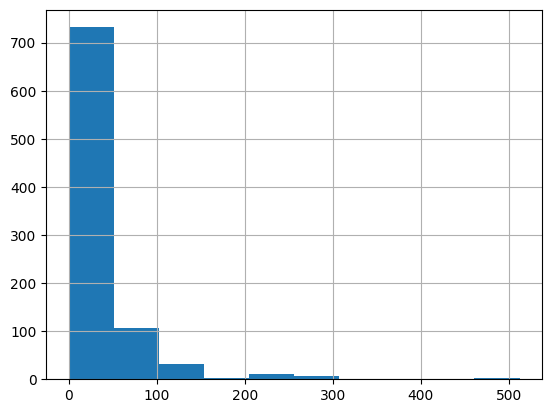

In [93]:
data['fare'].hist()

<Axes: xlabel='age', ylabel='fare'>

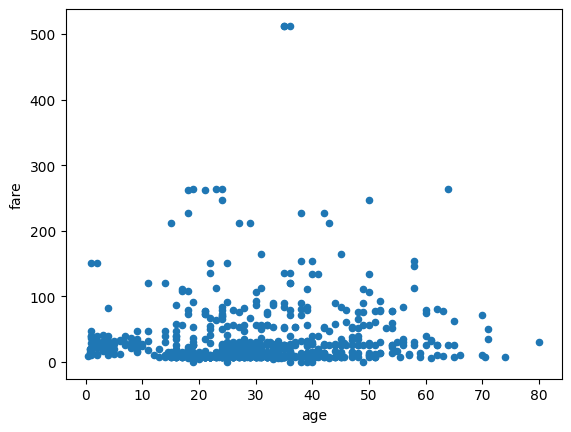

In [94]:
data.plot.scatter(x="age", y="fare")

<Axes: >

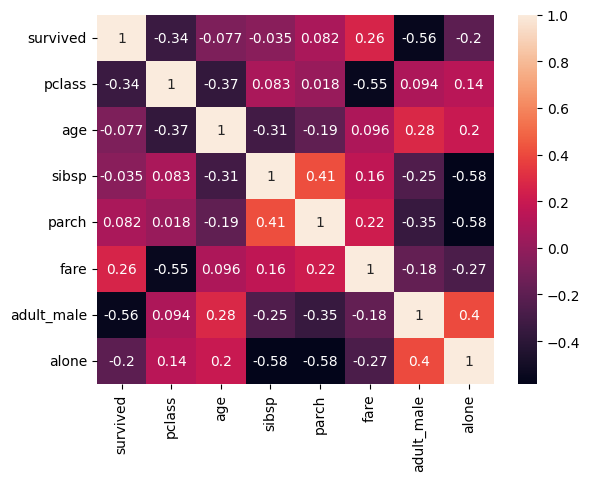

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data.corr(numeric_only = True), annot=True)

## Exercises

Perform some basic operations on the planets (i.e., exoplanets) toy dataset.

In [96]:
import seaborn as sns

planets = sns.load_dataset('planets')

1.- Visualize your raw data.

In [97]:
display(planets)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


2.- Identify the columns along with its datatype.

In [98]:
import pandas as pd

pd.DataFrame({
    'column': planets.columns,
    'dtype': planets.dtypes.values
})

,column,dtype
0,method,object
1,number,int64
2,orbital_period,float64
3,mass,float64
4,distance,float64
5,year,int64


3.- Remove any column without interest.

In [100]:
planets_clean = planets.drop(columns=['number'])
planets_clean

,method,orbital_period,mass,distance,year
0,Radial Velocity,269.300000,7.10,77.40,2006
1,Radial Velocity,874.774000,2.21,56.95,2008
2,Radial Velocity,763.000000,2.60,19.84,2011
3,Radial Velocity,326.030000,19.40,110.62,2007
4,Radial Velocity,516.220000,10.50,119.47,2009
...,...,...,...,...,...
1030,Transit,3.941507,NaN,172.00,2006
1031,Transit,2.615864,NaN,148.00,2007
1032,Transit,3.191524,NaN,174.00,2007
1033,Transit,4.125083,NaN,293.00,2008


4.- Obtain some summary statistics.

In [101]:
planets.describe()

,number,orbital_period,mass,distance,year
count,1035.000000,992.000000,513.000000,808.000000,1035.000000
mean,1.785507,2002.917596,2.638161,264.069282,2009.070531
std,1.240976,26014.728304,3.818617,733.116493,3.972567
min,1.000000,0.090706,0.003600,1.350000,1989.000000
25%,1.000000,5.442540,0.229000,32.560000,2007.000000
50%,1.000000,39.979500,1.260000,55.250000,2010.000000
75%,2.000000,526.005000,3.040000,178.500000,2012.000000
max,7.000000,730000.000000,25.000000,8500.000000,2014.000000


5.- Determine the number of NaNs that your dataset contains.

In [102]:
# NaNs per column
print(planets.isna().sum())

# Total NaNs in the whole dataset
print("Total NaNs:", planets.isna().sum().sum())

method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64
Total NaNs: 792


6.- Remove those rows with NaNs.

In [104]:
planets_no_nan = planets.dropna()
print("Original shape:", planets.shape)
print("Without NaNs shape:", planets_no_nan.shape)

Original shape: (1035, 6)
Without NaNs shape: (498, 6)


7.- Identify the exoplanets detection methods.

In [107]:
planets['method'].unique()

array(['Radial Velocity', 'Imaging', 'Eclipse Timing Variations',
       'Transit', 'Astrometry', 'Transit Timing Variations',
       'Orbital Brightness Modulation', 'Microlensing', 'Pulsar Timing',
       'Pulsation Timing Variations'], dtype=object)

8.- Compute the number of planets detected by each method.

In [108]:
planets['method'].value_counts()

,count
method,
Radial Velocity,553
Transit,397
Imaging,38
Microlensing,23
Eclipse Timing Variations,9
Pulsar Timing,5
Transit Timing Variations,4
Orbital Brightness Modulation,3
Astrometry,2


9.- Obtain the main statistics (mean, median, standard deviation, maximum and minimum) of the explanets grouped by detection method.

In [112]:
numeric_cols = planets.select_dtypes(include='number').columns

stats_by_method = (
    planets.groupby('method')[numeric_cols]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(2)
)

display(stats_by_method)

number                      orbital_period  \
                                mean median   std min max           mean   
method                                                                     
Astrometry                      1.00    1.0  0.00   1   1         631.18   
Eclipse Timing Variations       1.67    2.0  0.50   1   2        4751.64   
Imaging                         1.32    1.0  0.93   1   4      118247.74   
Microlensing                    1.17    1.0  0.39   1   2        3153.57   
Orbital Brightness Modulation   1.67    2.0  0.58   1   2           0.71   
Pulsar Timing                   2.20    3.0  1.10   1   3        7343.02   
Pulsation Timing Variations     1.00    1.0   NaN   1   1        1170.00   
Radial Velocity                 1.72    1.0  1.16   1   6         823.35   
Transit                         1.95    1.0  1.40   1   7          21.10   
Transit Timing Variations       2.25    2.0  0.50   2   3          79.78   

                                                                        ...  \
                                 median        std      min        max  ...   
method                                                                  ...   
Astrometry                       631.18     544.22   246.36    1016.00  ...   
Eclipse Timing Variations       4343.50    2499.13  1916.25   10220.00  ...   
Imaging                        27500.00  213978.18  4639.15  730000.00  ...   
Microlensing                    3300.00    1113.17  1825.00    5100.00  ...   
Orbital Brightness Modulation      0.34       0.73     0.24       1.54  ...   
Pulsar Timing                     66.54   16313.27     0.09   36525.00  ...   
Pulsation Timing Variations     1170.00        NaN  1170.00    1170.00  ...   
Radial Velocity                  360.20    1454.93     0.74   17337.50  ...   
Transit                            5.71      46.19     0.36     331.60  ...   
Transit Timing Variations         57.01      71.60    22.34     160.00  ...   

                              distance                                      \
                                  mean   median      std      min      max   
method                                                                       
Astrometry                       17.88    17.88     4.09    14.98    20.77   
Eclipse Timing Variations       315.36   315.36   213.20   130.72   500.00   
Imaging                          67.72    40.39    53.74     7.69   165.00   
Microlensing                   4144.00  3840.00  2076.61  1760.00  7720.00   
Orbital Brightness Modulation  1180.00  1180.00     0.00  1180.00  1180.00   
Pulsar Timing                  1200.00  1200.00      NaN  1200.00  1200.00   
Pulsation Timing Variations        NaN      NaN      NaN      NaN      NaN   
Radial Velocity                  51.60    40.44    45.56     1.35   354.00   
Transit                         599.30   341.00   913.88    38.00  8500.00   
Transit Timing Variations      1104.33   855.00   915.82   339.00  2119.00   

                                  year                            
                                  mean  median   std   min   max  
method                                                            
Astrometry                     2011.50  2011.5  2.12  2010  2013  
Eclipse Timing Variations      2010.00  2010.0  1.41  2008  2012  
Imaging                        2009.13  2009.0  2.78  2004  2013  
Microlensing                   2009.78  2010.0  2.86  2004  2013  
Orbital Brightness Modulation  2011.67  2011.0  1.15  2011  2013  
Pulsar Timing                  1998.40  1994.0  8.38  1992  2011  
Pulsation Timing Variations    2007.00  2007.0   NaN  2007  2007  
Radial Velocity                2007.52  2009.0  4.25  1989  2014  
Transit                        2011.24  2012.0  2.08  2002  2014  
Transit Timing Variations      2012.50  2012.5  1.29  2011  2014  

[10 rows x 25 columns]

10.- Visualize an histogram of each variable of interest.

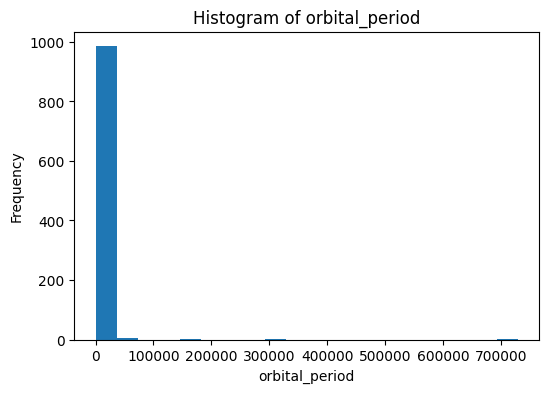

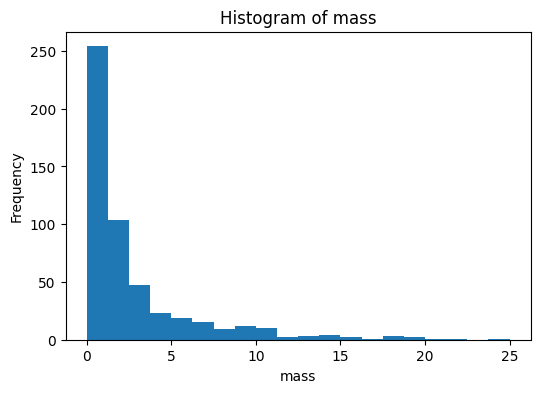

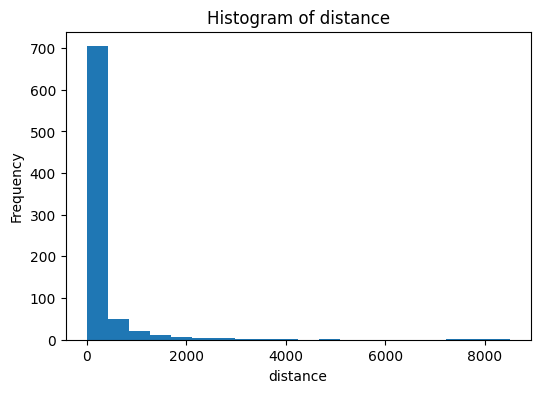

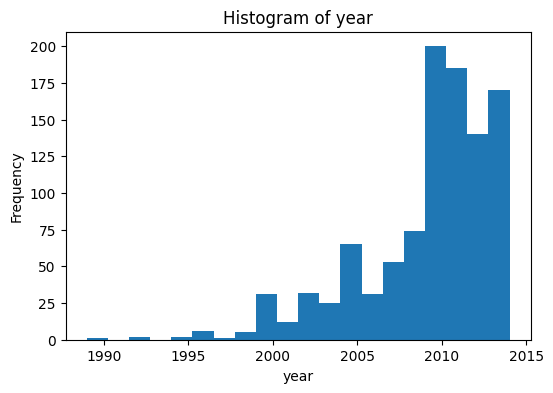

In [113]:
import matplotlib.pyplot as plt

vars_interest = ['orbital_period', 'mass', 'distance', 'year']

for col in vars_interest:
    plt.figure(figsize=(6, 4))
    planets[col].dropna().hist(bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.show()

11.- For each detection method, visualize an histogram of any column of your interest. Do it placing one histogram in one cell, use as many cells as you need. Take a subset of your dataset in each cell. (Next week we will learn a more convenient way to do it).

12.- Visualize an scatterplot for each pair of attributes of interest. Place each plot in a different cell, using as many cells as you need.